In [1]:
import sys
sys.path.insert(0, '../Results')
sys.path.insert(0, '../../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from python_utils.visualization_utils import create_summary_table, plot_snr_performance

In [2]:
if not os.path.exists("Figures"):
    os.mkdir("Figures")

# 10 by 5 Mixing with Noisy Inputs Results

In [3]:
df_predictiveBSS = pd.read_pickle(r"../Results/predictive_bss_noisy_sparse_10by5_results.pkl")
df_predictiveBSS.tail()

,Model,seed,SINR,SNR,SNRinp,execution_time
535,CorInfoMaxBSS,2800,7.217923,"[[5.852865399793363, 6.991929902070262, 7.0231...",5.0,28.954488
536,LDMIBSS,2800,7.201244,"[[5.9715748625720755, 7.031527499367078, 6.937...",5.0,21.983171
537,PredictiveDecorrBSS,2900,6.262000,"[[7.0473255216283555, 6.598797185895777, 4.076...",5.0,15.368832
538,CorInfoMaxBSS,2900,6.200001,"[[7.018658689103702, 6.436372138718321, 4.0793...",5.0,29.947699
539,LDMIBSS,2900,6.078808,"[[6.9253701042888345, 6.46727592363951, 3.8258...",5.0,22.129003


In [4]:
df_upem = pd.read_pickle(r"../Results/upem_noisy_sparse_10by5_results.pkl")
def interleave(A, B,k):
    nA, nB = len(A), len(B)

    # Group index for A (every k rows = one group)
    groups_A = np.arange(nA) // k

    # Position within each group (A rows come first)
    pos_A = np.arange(nA) % k

    # Build DataFrame with ordering keys
    A_ = A.copy()
    A_['_grp'] = groups_A
    A_['_pos'] = pos_A
    A_['_src'] = 0  # A comes before B within group

    # For B: one row per group
    B_ = B.iloc[:groups_A.max() + 1].copy()
    B_['_grp'] = np.arange(len(B_))
    B_['_pos'] = k   # comes after the 5 A rows
    B_['_src'] = 1

    # Combine and sort once
    out = pd.concat([A_, B_], ignore_index=True)
    out = out.sort_values(['_grp', '_pos', '_src'])

    return out.drop(columns=['_grp', '_pos', '_src']).reset_index(drop=True)
df_combined = interleave(df_predictiveBSS, df_upem,3)

In [5]:
summary_df = create_summary_table(df_combined)
summary_df

,,SINR (dB),mSNR (dB),Time (s)
Model,SNRinp,,,
CorInfoMaxBSS,5.0,6.76 ± 0.25,7.02 ± 0.21,26.64 ± 0.61
LDMIBSS,5.0,6.74 ± 0.27,6.99 ± 0.23,22.16 ± 0.17
PredictiveDecorrBSS,5.0,6.92 ± 0.26,7.19 ± 0.22,12.81 ± 0.35
PredictiveDecorrBSSSimple,5.0,6.93 ± 0.26,7.20 ± 0.22,5.87 ± 0.27
CorInfoMaxBSS,10.0,10.71 ± 0.38,11.08 ± 0.32,24.99 ± 0.49
LDMIBSS,10.0,10.67 ± 0.39,11.02 ± 0.34,22.14 ± 0.14
PredictiveDecorrBSS,10.0,10.89 ± 0.38,11.26 ± 0.32,13.81 ± 0.21
PredictiveDecorrBSSSimple,10.0,10.88 ± 0.38,11.26 ± 0.32,6.18 ± 0.36
CorInfoMaxBSS,15.0,15.16 ± 0.47,15.59 ± 0.39,25.53 ± 0.47


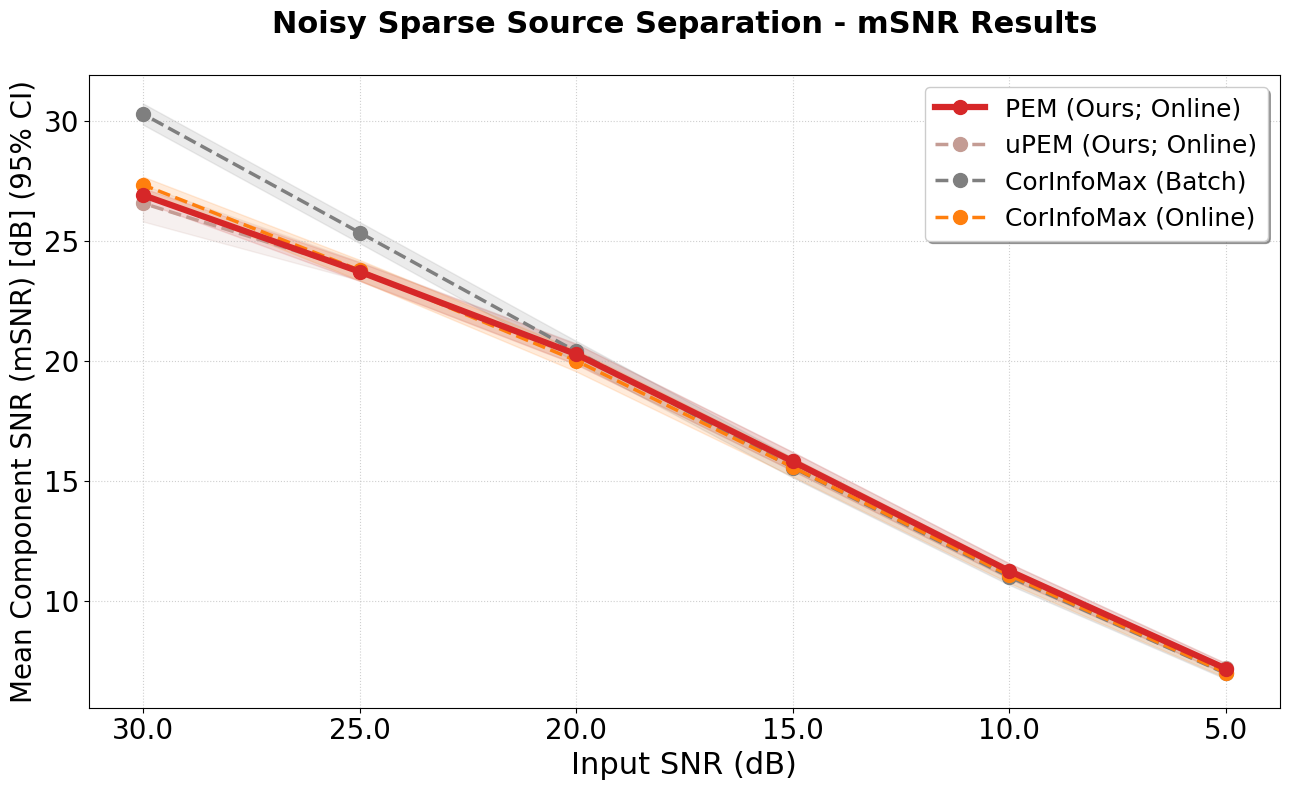

In [6]:
plot_title = "Noisy Sparse Source Separation - mSNR Results"
bss_plot = plot_snr_performance(summary_df, 'SNRinp', title = plot_title)
# plt.savefig('Figures/Sparse_Noisy_Comparison.pdf', format='pdf', bbox_inches = 'tight')
bss_plot.show()